# DEVOIR CLASSIFICATION CHIEN ET CHAT - DOMINIQUE FOTSING

## Preparation de l'environnement de travail et import des bibliotheques

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
import helper
import numpy as np
import os
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import torch
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from torchvision.models import resnet18, ResNet18_Weights


## Detection si le GPU est disponible ou disponible sur la machine qui execute les frameworks des differents tensors et les modeles - Le Runtime T4-GPU de collab est active

In [ ]:
# Détecter le GPU si disponible, sinon basculer sur le CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Périphérique sélectionné : {device}")

if device.type == "cuda":
    print(f"GPU disponible : {torch.cuda.get_device_name(0)}")
else:
    # Affiche le nombre de cœurs CPU disponibles
    nb_cpus = os.cpu_count()
    print(f"CPU utilisé ({nb_cpus} cœurs disponibles)")

Périphérique sélectionné : cuda
GPU disponible : Tesla T4


## Definition du repertoire de travail

In [ ]:
%cd /content/drive/MyDrive/Deep_learning/cnn_cat_dog_image_classification

/content/drive/MyDrive/Deep_learning/cnn_cat_dog_image_classification


## Préparation et chargement du jeu d'images d'entraînement (chats et chiens contenu dans le dossier Cat_Dog_data)

In [ ]:
data_dir = 'Cat_Dog_data/train'

#transform = # TODO: compose transforms here
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

#dataset = # TODO: create the ImageFolder
dataset = datasets.ImageFolder(data_dir, transform=transform)

#dataloader = # TODO: use the ImageFolder dataset to create the DataLoader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

## Affichage de l'image sous forme de tenseur en graphique

In [ ]:

def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()

    image = image.numpy().transpose((1, 2, 0))

    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

## Test du data loader pour s'assurer que le chargement et la transformation de deroule bien

<Axes: >

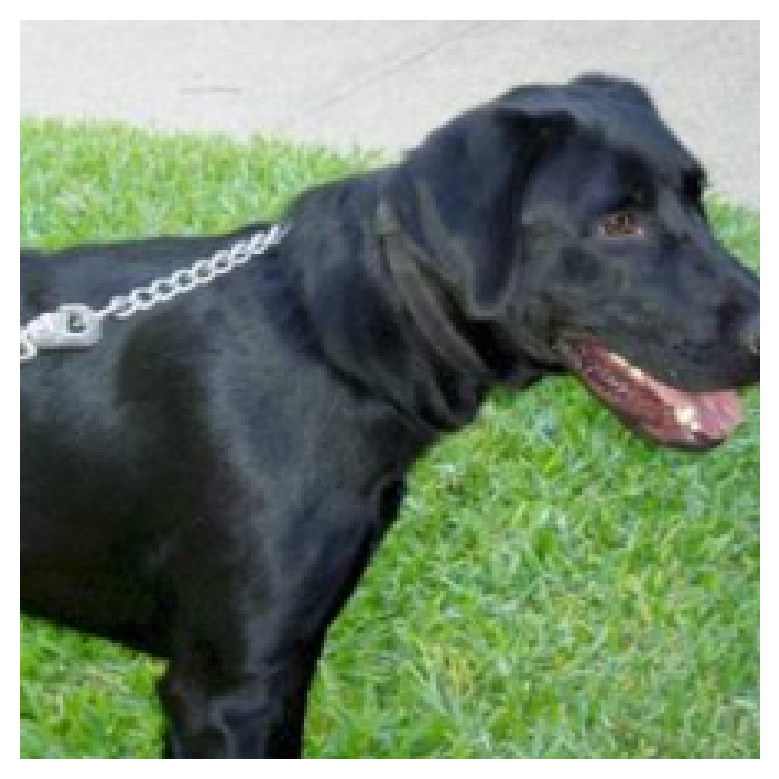

In [ ]:
# Run this to test your data loader
images, labels = next(iter(dataloader))
imshow(images[0], normalize=False)

## Preparation des donnees d'entrainement, de test et augmentation des donnees (Data Augmentation)

In [ ]:
# code ameliore

data_dir = 'Cat_Dog_data'

# --- TRANSFORMS D'ENTRAÎNEMENT (avec Data Augmentation) ---
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),          # Découpe et redimensionne en 224x224
    transforms.RandomHorizontalFlip(p=0.5),      # Inversion horizontale aléatoire
    transforms.RandomRotation(degrees=15),       # Rotation légère (-15° à +15°)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Variations de couleur
    transforms.ToTensor()                        # Convertit en Tensor et passe les pixels de [0, 255] à [0.0, 1.0]
])

# --- TRANSFORMS DE TEST / VALIDATION ---
test_transforms = transforms.Compose([
    transforms.Resize(255),                      # Redimensionne le petit côté à 255px
    transforms.CenterCrop(224),                  # Rogne au centre à 224x224
    transforms.ToTensor()                        # Convertit en Tensor [0.0, 1.0]
])

# Chargement des datasets
train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + '/test', transform=test_transforms)

# DataLoaders
trainloader = torch.utils.data.DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,       # Indispensable pour l'entraînement
    num_workers=2,
    pin_memory=True
)

testloader = torch.utils.data.DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [ ]:
# change this to the trainloader or testloader
data_iter = iter(trainloader)

In [ ]:
images, labels = next(data_iter)
labels

tensor([0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 1, 0, 1, 0])

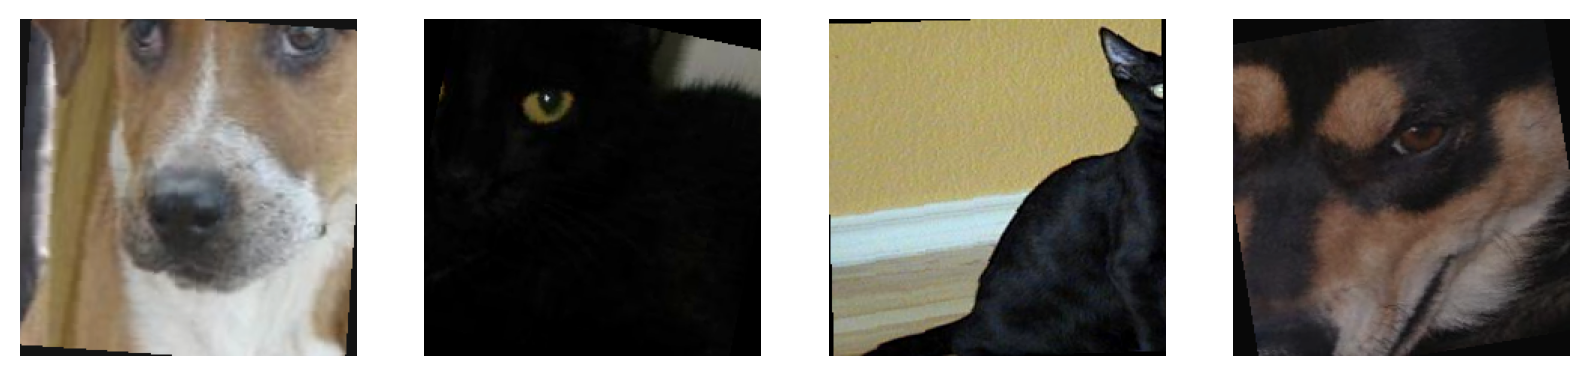

In [ ]:
images, labels = next(data_iter)
fig, axes = plt.subplots(figsize=(10,4), ncols=4)
for ii in range(4):
    ax = axes[ii]
    imshow(images[ii], ax=ax, normalize=False)

## Fixation du seed pour s'assurer de la reproductibilite du code et modele

In [ ]:
def fix_seed(seed=75):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Garantit des opérations déterministes sur GPU
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Seed fixé à : {seed}")

# Appliquer le seed avant la création du modèle
fix_seed(75)

Seed fixé à : 75


## Définition du Modèle
#### 1. Extraction des caractéristiques (Feature Extraction)
Le réseau enchaîne 5 blocs convolutifs successifs. À chaque étape, le réseau extrait des motifs visuels de plus en plus complexes (bords $\rightarrow$ textures $\rightarrow$ formes $\rightarrow$ parties de corps) tout en réduisant la taille de l'image :
Chaque bloc applique l'ordre standard suivant :
$$\text{Convolution} \rightarrow \text{BatchNorm} \rightarrow \text{ReLU} \rightarrow \text{MaxPooling}$$
- Convolution (Conv2d) : Multiplie le nombre de canaux pour détecter plus de caractéristiques (passe de 3 canaux RVB $\rightarrow$ 16 $\rightarrow$ 32 $\rightarrow$ 64 $\rightarrow$ 128 $\rightarrow$ 256).
- Batch Normalization (BatchNorm2d) : Normalise les activations à la sortie de la convolution, ce qui stabilise et accélère grandement l'entraînement.
- Activation (F.relu) : Ajoute de la non-linéarité pour permettre au réseau d'apprendre des motifs complexes.
- Max Pooling (MaxPool2d) : Divise la hauteur et la largeur de l'image par 2 à chaque étape ($224\times224 \rightarrow 112\times112 \rightarrow 56\times56 \rightarrow 28\times28 \rightarrow 14\times14 \rightarrow 7\times7$).
#### 2. Aplatissement (Flattening) (x.view(x.size(0), -1))
Cette ligne, x.view(x.size(0), -1) transforme la grille 3D de caractéristiques ($256 \times 7 \times 7$) en un simple vecteur 1D de $12\ 544$ valeurs pour chaque image du batch, afin de pouvoir le passer aux couches denses.
#### 3. Classification (Classifier)
Cette partie prend les caractéristiques extraites et calcule la décision finale :
- fc1 + bn_fc1 : Réduit le vecteur de $12\ 544$ valeurs à $512$ neurones avec une couche de normalisation 1D.
- dropout (25%) : Désactive aléatoirement 25% des neurones pendant l'entraînement pour éviter le surapprentissage (overfitting).
- fc2 : Couche de sortie finale qui génère $2$ scores (logits) correspondants aux 2 classes (Chat et Chien).

In [ ]:
class ClassificationChienChat(nn.Module):
    def __init__(self, num_classes=2):
        super(ClassificationChienChat, self).__init__()

        # 1. Conv1 + BatchNorm1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        # 2. Conv2 + BatchNorm2
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # 3. Conv3 + BatchNorm3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        # 4. Conv4 + BatchNorm4
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        # 5. Conv5 + BatchNorm5
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)

        # MaxPool2d partagé
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Couches Fully-Connected et BatchNorm1d
        self.fc1 = nn.Linear(256 * 7 * 7, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)

        # Dropout à 0.25
        self.dropout = nn.Dropout(0.25)

        # Sortie vers num_classes
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Ordre standard : Convolution -> BatchNorm -> Activation ReLU -> Pooling
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # (16, 112, 112)
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # (32, 56, 56)
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) # (64, 28, 28)
        x = self.pool(F.relu(self.bn4(self.conv4(x)))) # (128, 14, 14)
        x = self.pool(F.relu(self.bn5(self.conv5(x)))) # (256, 7, 7)

        # Aplatissement dynamique (Flatten)
        x = x.view(x.size(0), -1)

        # Couches Fully-Connected avec BatchNorm1d
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)

        return x



## Instanciation du Modèle et transfere sur le type de processeur detecte

In [ ]:
model = ClassificationChienChat().to(device)
print(model)

ClassificationChienChat(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=12544, out_features=512, bia

## Définition de la fonction de perte (Loss Function)

Pour un problème de classification multi-classes ou binaire avec 2 sorties, nn.CrossEntropyLoss() est la norme. Elle combine automatiquement un LogSoftmax et une perte de type Negative Log Likelihood (NLLLoss) pour indiquer à quel point le modèle se trompe dans ses prédictions.

Plus la valeur de la perte est proche de 0, plus les prédictions du modèle sont justes et confiantes.


In [ ]:
# 3. Fonction de perte
criterion = nn.CrossEntropyLoss()


## Entrainement des modeles avec deux optimiseurs SDG et ADAM a 10 epoques et comparaison avec ajustement du learning rate grace au scheduleur et sauvegarde des meilleurs poids dans le drive



In [ ]:
# 1. Configuration des paramètres
num_epochs = 10

# 2. Définition de la fonction d'entraînement avec Scheduler et Sauvegarde des poids
def entrainer_avec_optimiseur(model, dataloader, optimizer, scheduler, num_epochs, name="Optimiseur", save_path=None):
    print(f"\n==========================================")
    print(f"--- Entraînement avec : {name} ---")
    print(f"==========================================")

    # Historique pour la comparaison graphique
    history = {'loss': [], 'acc': [], 'lr': []}

    # Initialisation de la meilleure perte (infinie au départ)
    best_loss = float('inf')

    for epoch in range(num_epochs):
        # Mode entraînement (active le Dropout et la BatchNorm)
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        # Parcourir les lots de données (batches)
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # a. Remise à zéro des gradients
            optimizer.zero_grad()

            # b. Passage avant (Forward pass)
            outputs = model(images)

            # c. Calcul de la perte
            loss = criterion(outputs, labels)

            # d. Rétropropagation (Backpropagation)
            loss.backward()

            # e. Mise à jour des poids
            optimizer.step()

            # --- Statistiques ---
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            total += labels.size(0)

        # Métriques moyennes de l'époque
        epoch_loss = running_loss / total
        epoch_acc = (correct / total) * 100

        # f. Mise à jour du Learning Rate Scheduler
        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(epoch_loss)
        else:
            scheduler.step()

        # Récupération du taux d'apprentissage actuel
        current_lr = optimizer.param_groups[0]['lr']

        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        history['lr'].append(current_lr)

        # ==============================================================================
        # g. SAUVEGARDE DES MEILLEURS POIDS
        # ==============================================================================
        sauvegarde_msg = ""
        if save_path and epoch_loss < best_loss:
            best_loss = epoch_loss
            # Sauvegarde uniquement des poids du modèle (state_dict)
            torch.save(model.state_dict(), save_path)
            sauvegarde_msg = f" --> [Meilleurs poids sauvegardés : {save_path}]"

        print(f"Époque [{epoch + 1}/{num_epochs}] - Loss: {epoch_loss:.4f} | Précision: {epoch_acc:.2f}% | LR: {current_lr:.6f}{sauvegarde_msg}")

    return history

# ==============================================================================
# 3. Lancement des deux entraînements avec sauvegarde distincte
# ==============================================================================

# Instanciation de deux modèles identiques
model_adam = ClassificationChienChat().to(device)
model_sgd = copy.deepcopy(model_adam)

# Configuration des 2 optimiseurs

#Ancien parametre des optimiseurs
#optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)
#optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)

# Nouveau parametre pour ameliorer le modele (ajout L2 (Weight Decay))
optimizer_adam = torch.optim.AdamW(model_adam.parameters(), lr=0.001, weight_decay=1e-2)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01,momentum=0.9, weight_decay=1e-4)

# Configuration des Schedulers pour chaque optimiseur
scheduler_adam = ReduceLROnPlateau(optimizer_adam, mode='min', factor=0.5, patience=1)
scheduler_sgd = ReduceLROnPlateau(optimizer_sgd, mode='min', factor=0.5, patience=1)

# Lancement pour ADAM (Sauvegarde dans 'meilleur_modele_adam.pt')
history_adam = entrainer_avec_optimiseur(
    model_adam,
    dataloader,
    optimizer_adam,
    scheduler_adam,
    num_epochs,
    name="Adam",
    save_path="meilleur_modele_adam.pt"
)

# Lancement pour SGD (Sauvegarde dans 'meilleur_modele_sgd.pt')
history_sgd = entrainer_avec_optimiseur(
    model_sgd,
    dataloader,
    optimizer_sgd,
    scheduler_sgd,
    num_epochs,
    name="SGD avec Momentum",
    save_path="meilleur_modele_sgd.pt"
)


--- Entraînement avec : Adam ---
Époque [1/10] - Loss: 0.4814 | Précision: 77.91% | LR: 0.001000 --> [Meilleurs poids sauvegardés : meilleur_modele_adam.pt]
Époque [2/10] - Loss: 0.3802 | Précision: 83.35% | LR: 0.001000 --> [Meilleurs poids sauvegardés : meilleur_modele_adam.pt]
Époque [3/10] - Loss: 0.3171 | Précision: 86.52% | LR: 0.001000 --> [Meilleurs poids sauvegardés : meilleur_modele_adam.pt]
Époque [4/10] - Loss: 0.2715 | Précision: 88.77% | LR: 0.001000 --> [Meilleurs poids sauvegardés : meilleur_modele_adam.pt]
Époque [5/10] - Loss: 0.2237 | Précision: 90.56% | LR: 0.001000 --> [Meilleurs poids sauvegardés : meilleur_modele_adam.pt]
Époque [6/10] - Loss: 0.1763 | Précision: 92.88% | LR: 0.001000 --> [Meilleurs poids sauvegardés : meilleur_modele_adam.pt]
Époque [7/10] - Loss: 0.1416 | Précision: 94.39% | LR: 0.001000 --> [Meilleurs poids sauvegardés : meilleur_modele_adam.pt]
Époque [8/10] - Loss: 0.1019 | Précision: 96.16% | LR: 0.001000 --> [Meilleurs poids sauvegardés :

### Premier entrainement avec 5 epoques
Au premier entrainement, Adam est plus rapide et plus performant car le cap des 90% de precision à l'epoque 5, la ou SGD plafonne a 88.66%. Mais on constate que les modeles n'ont pas encore fini d'apprendre car la perte diminue de maniere constante a chaque epoque sans aucune oscillation, reste significative a 0.2223 et la courbe n'atteint de plateau.

Quand on analyse les donnees de la matrice de confusion et les donnees statistiques obtenues plus bas dans l'evaluation des modeles, on confirme qu'il y a surapprentissage, Adam souffre d'un surpraprentissage severe avec un bias marque vers la classe "chat".

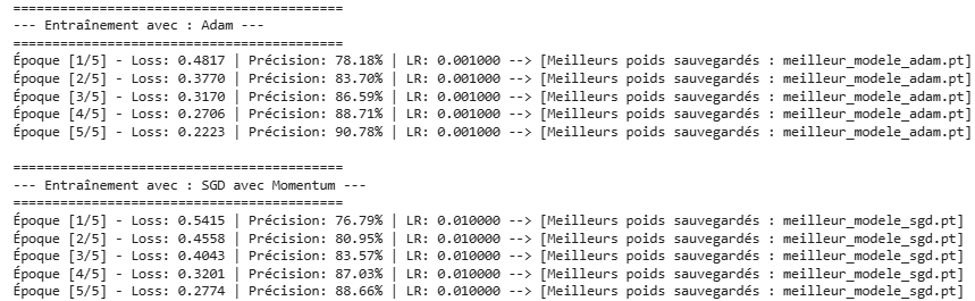

Initialement les optimiseurs ont ete configures comme suit:
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)

On va faire une regularisation avec l'introduction de $L_2$ (Weight Decay) en modifiant les optimiseurs comme suit:

optimizer_adam = torch.optim.AdamW(model_adam.parameters(), lr=0.001, weight_decay=1e-2)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01,momentum=0.9, weight_decay=1e-4)

On doit aussi augmenter le nombre d'epoques a 10 car 5 epoques on a egalement constate que la courbe n'a pas atteint le plateau.

### Bilan du second entrainement avec regularisation des optimiseurs et passage a 10 epoques
- En passant de 5 à 10 époques, la précision a bondi : Adam atteint 97.86% et SGD atteint 96.60%
- La perte de perte (Loss) est devenue extrêmement faible pour les deux modèles ($0.0614$ pour Adam et $0.0918$ pour SGD), ce qui signifie que le réseau maîtrise désormais quasi-parfaitement les images d'entraînement.
- Adam conserve son avantage en vitesse et precision d'apprentissage.
- Le scheduleur (ReduceLROnPlateau) n'a pas ete actif car Le taux d'apprentissage est resté bloqué à sa valeur initiale ($0.001$ pour Adam, $0.01$ pour SGD)

## Comparaison graphique des deux optimiseurs

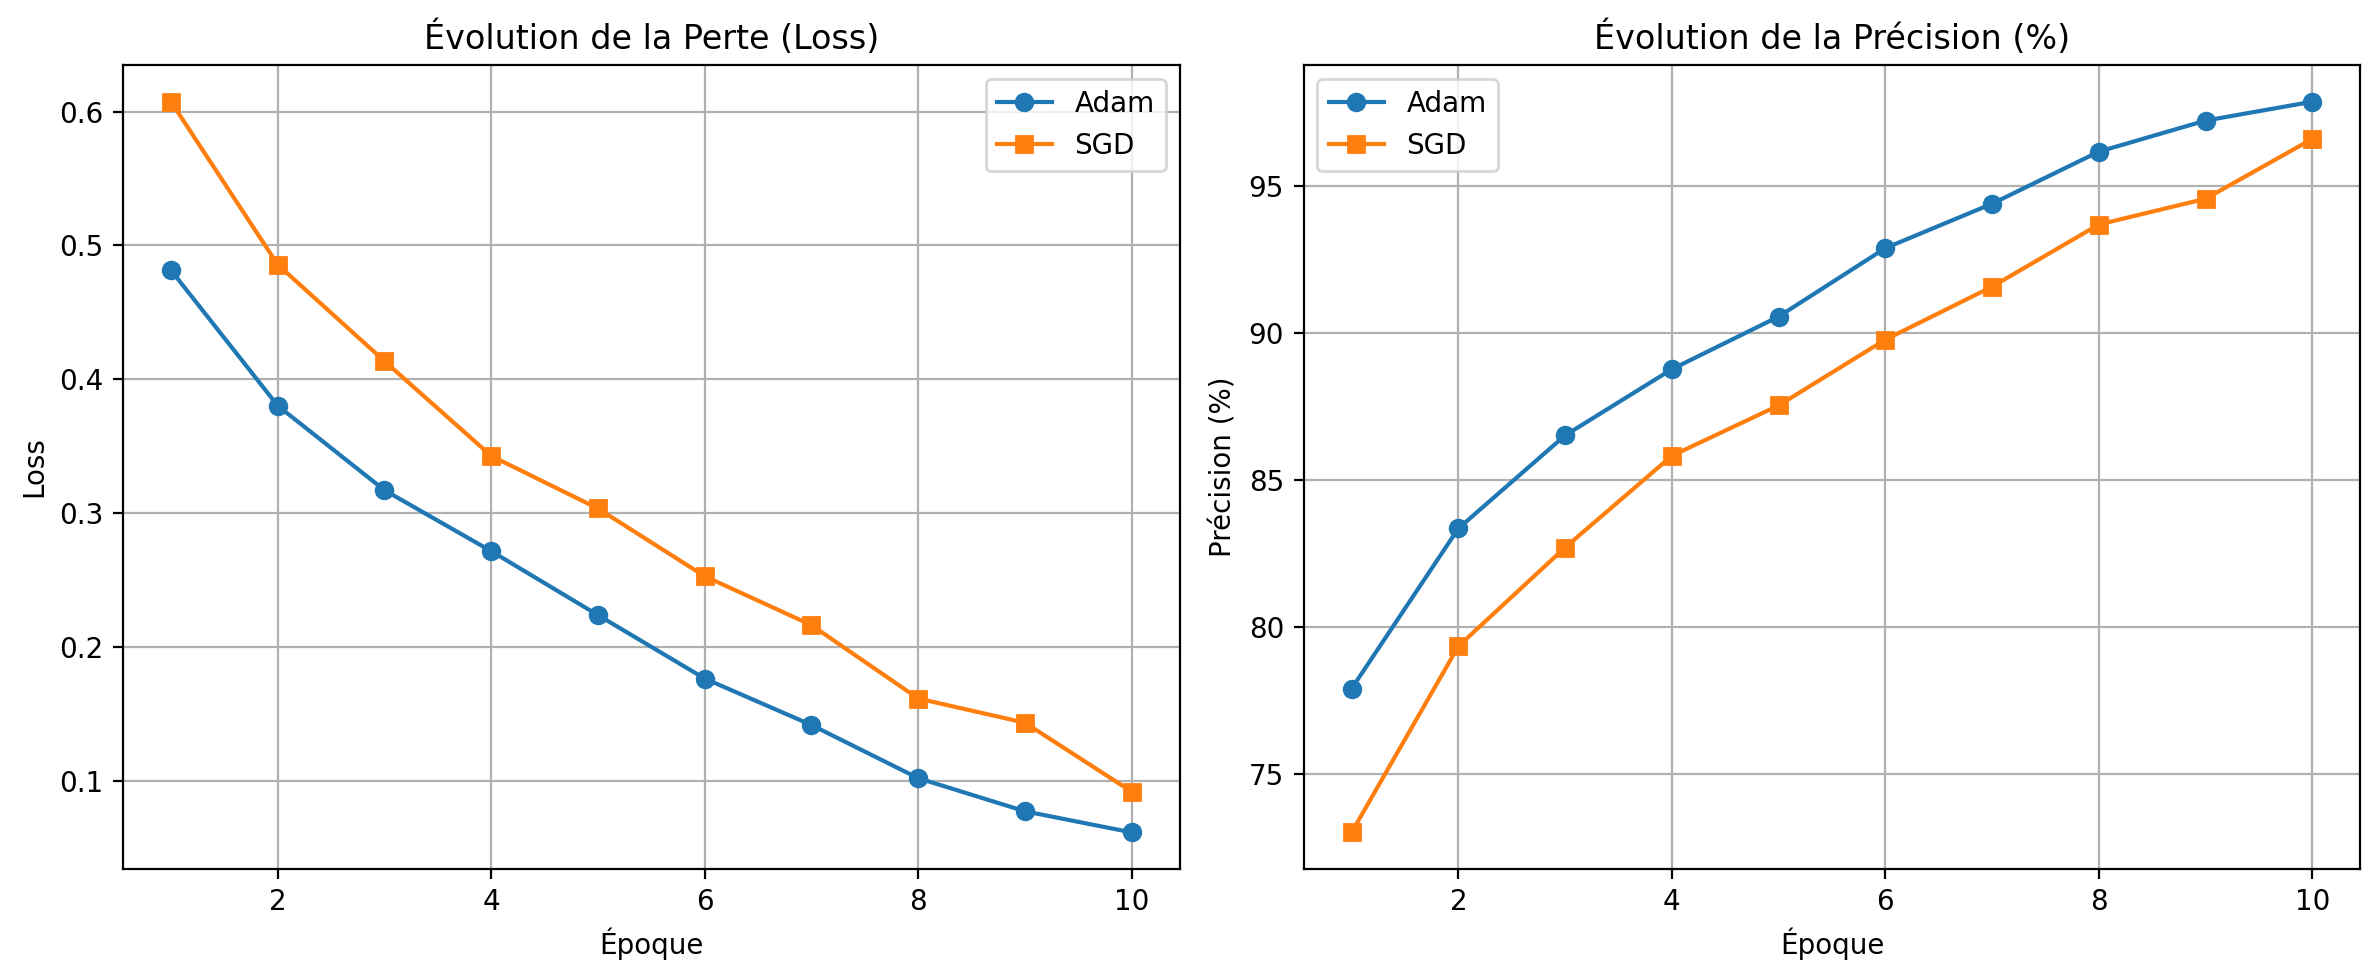

In [ ]:
plt.figure(figsize=(12, 5))

# Graphique de la Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history_adam['loss'], label='Adam', marker='o')
plt.plot(range(1, num_epochs + 1), history_sgd['loss'], label='SGD', marker='s')
plt.title('Évolution de la Perte (Loss)')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Graphique de la Précision (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), history_adam['acc'], label='Adam', marker='o')
plt.plot(range(1, num_epochs + 1), history_sgd['acc'], label='SGD', marker='s')
plt.title('Évolution de la Précision (%)')
plt.xlabel('Époque')
plt.ylabel('Précision (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluation des modeles avec 10 epoques avec regularisation des optimiseurs

Chargement des poids depuis meilleur_modele_adam.pt...

           RÉSULTATS DE L'ÉVALUATION      
Perte (Test Loss)       : 0.3663
Précision (Accuracy)    : 87.68%
Rappel (Recall)         : 0.8768
F1-Score                : 0.8768

--- Rapport Détaillé par Classe ---
              precision    recall  f1-score   support

        Chat     0.8685    0.8880    0.8782      1250
       Chien     0.8854    0.8656    0.8754      1250

    accuracy                         0.8768      2500
   macro avg     0.8770    0.8768    0.8768      2500
weighted avg     0.8770    0.8768    0.8768      2500



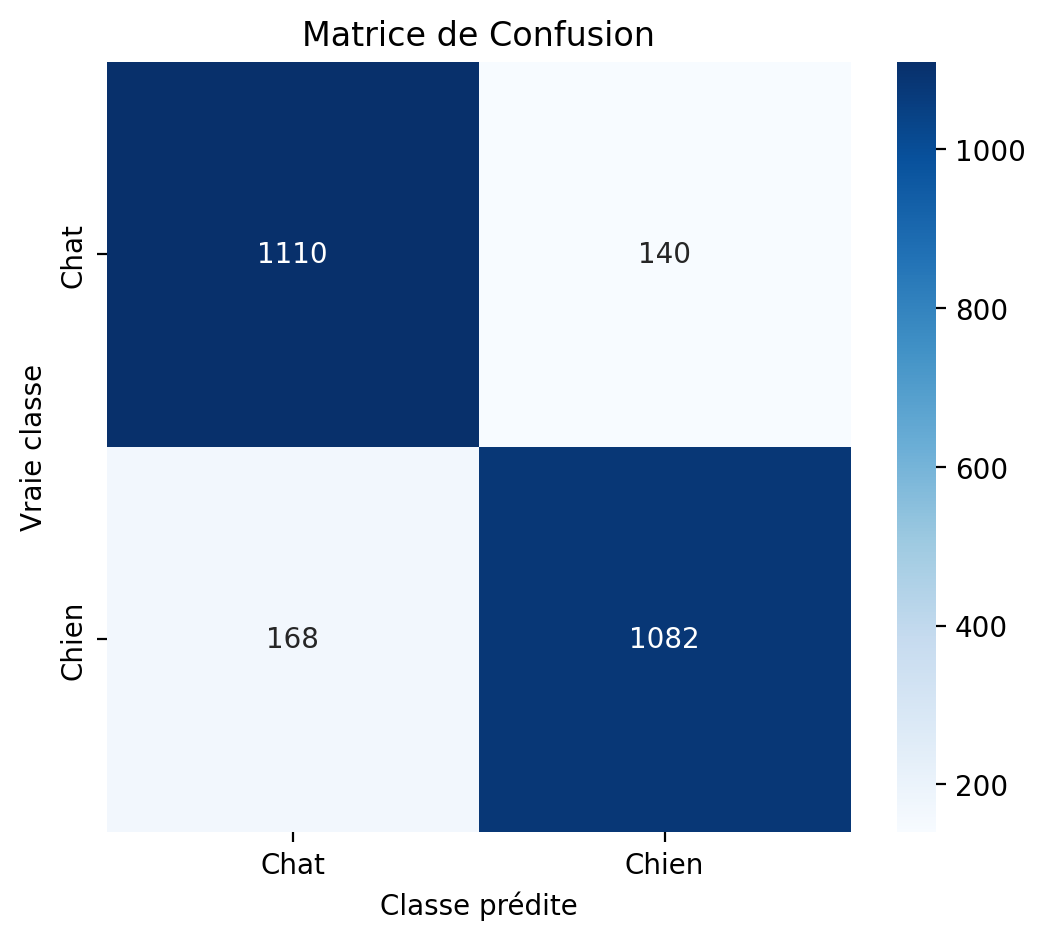

Chargement des poids depuis meilleur_modele_sgd.pt...

           RÉSULTATS DE L'ÉVALUATION      
Perte (Test Loss)       : 0.4642
Précision (Accuracy)    : 83.72%
Rappel (Recall)         : 0.8372
F1-Score                : 0.8370

--- Rapport Détaillé par Classe ---
              precision    recall  f1-score   support

        Chat     0.8630    0.8016    0.8312      1250
       Chien     0.8148    0.8728    0.8428      1250

    accuracy                         0.8372      2500
   macro avg     0.8389    0.8372    0.8370      2500
weighted avg     0.8389    0.8372    0.8370      2500



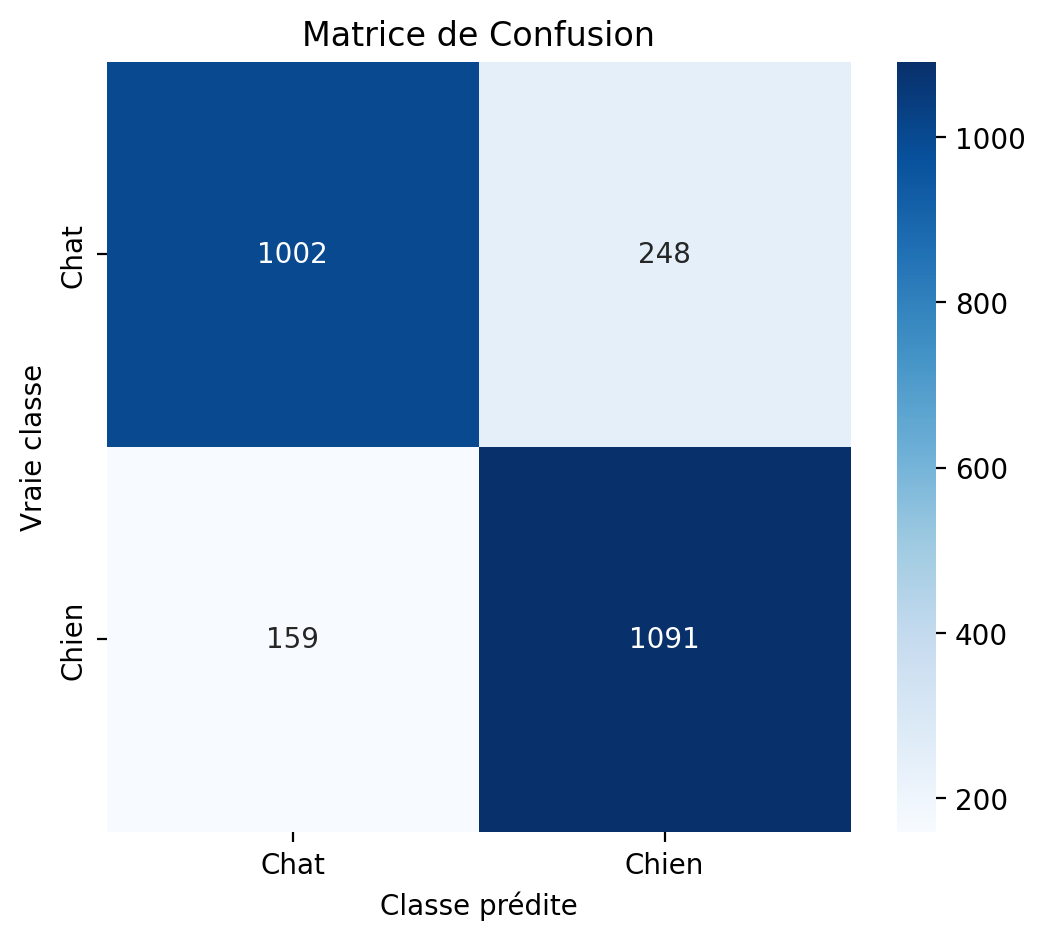

In [ ]:
def evaluer_modele(model, test_dataloader, criterion, save_path=None, class_names=['Chat', 'Chien']):
    """
    Évalue un modèle sur un DataLoader de test et calcule la Loss, l'Accuracy,
    le Recall, le F1-score et la matrice de confusion.
    """
    # 1. Charger les meilleurs poids sauvegardés si un chemin est spécifié
    if save_path:
        print(f"Chargement des poids depuis {save_path}...")
        model.load_state_dict(torch.load(save_path, map_location=device))

    # 2. Mode évaluation (désactive Dropout et BatchNorm)
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    # 3. Désactiver le calcul des gradients
    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistiques
            running_loss += loss.item() * images.size(0)

            # Prédictions
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 4. Calcul des métriques
    total_samples = len(all_labels)
    test_loss = running_loss / total_samples
    test_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100

    # Calcul de la Précision, du Recall et du F1-score globaux (moyenne macro)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    # 5. Affichage des métriques clés
    print("\n==========================================")
    print("           RÉSULTATS DE L'ÉVALUATION      ")
    print("==========================================")
    print(f"Perte (Test Loss)       : {test_loss:.4f}")
    print(f"Précision (Accuracy)    : {test_acc:.2f}%")
    print(f"Rappel (Recall)         : {recall:.4f}")
    print(f"F1-Score                : {f1:.4f}\n")

    # 6. Rapport de classification détaillé par classe
    print("--- Rapport Détaillé par Classe ---")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # 7. Affichage de la Matrice de Confusion
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion')
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.show()

# ==============================================================================
# Exemple d'appel de la fonction
# ==============================================================================

modele_a_evaluer = ClassificationChienChat().to(device)

evaluer_modele(
    model=modele_a_evaluer,
    test_dataloader=testloader, # À remplacer par votre DataLoader de test
    criterion=criterion,
    save_path="meilleur_modele_adam.pt",
    class_names=['Chat', 'Chien']
)

modele_a_evaluer = ClassificationChienChat().to(device)

evaluer_modele(
    model=modele_a_evaluer,
    test_dataloader=testloader, # À remplacer par votre DataLoader de test
    criterion=criterion,
    save_path="meilleur_modele_sgd.pt",
    class_names=['Chat', 'Chien']
)




### Bilan du second evaluation sur le jeu de test
Les résultats de cette réévaluation confirment l'efficacité de la régularisation et de la prolongation de l'entraînement : Adam devient le modèle le plus performant et le plus équilibré confirme par la matrice de confusion et les statistiques d'evaluation contrairement a l'evaluation du premier entrainement (ci-dessous), ou les donnees d'entrainement etaient bonnes et en faveur d'Adam mais etaient mise en difficulte lors de l'evaluation et la matrice de confusion.

Contrairement au premier modele avant regulation Adam classifie correctement 1 110 chats et 1 082 chiens (avant 1239 chats et 578 chiens seulement). La régularisation a forcé le réseau à mieux calibrer ses probabilités brutes.  

SGD progresse mais plafonne (83.72%)   SGD passe de 76.56% à 83.72% d'exactitude. Bien qu'il soit très stable, il manque d'adaptabilité par rapport à Adam pour extraire les motifs fins des images.   

Adam atteint 87,68% d'exactitude sur un jeu de données de test ce qui est une excellente performance.

## Evaluation des modeles avec 5 epoques sans regularisation des optimiseurs
NE PAS EXECUTER CETTE CELLULE, J'AI GARDE JUSTE POUR MONTRER LES RESULTATS SUR LE JEU DE TEST AVANT LA REGULARISATION DU MODELE

Chargement des poids depuis meilleur_modele_adam.pt...

           RÉSULTATS DE L'ÉVALUATION      
Perte (Test Loss)       : 0.9087
Exactitude (Accuracy)   : 72.68%
Précision (Precision)   : 0.8148
Rappel (Recall)         : 0.7268
F1-Score                 : 0.7063

--- Rapport Détaillé par Classe ---
              precision    recall  f1-score   support

        Chat     0.6484    0.9912    0.7839      1250
       Chien     0.9813    0.4624    0.6286      1250

    accuracy                         0.7268      2500
   macro avg     0.8148    0.7268    0.7063      2500
weighted avg     0.8148    0.7268    0.7063      2500



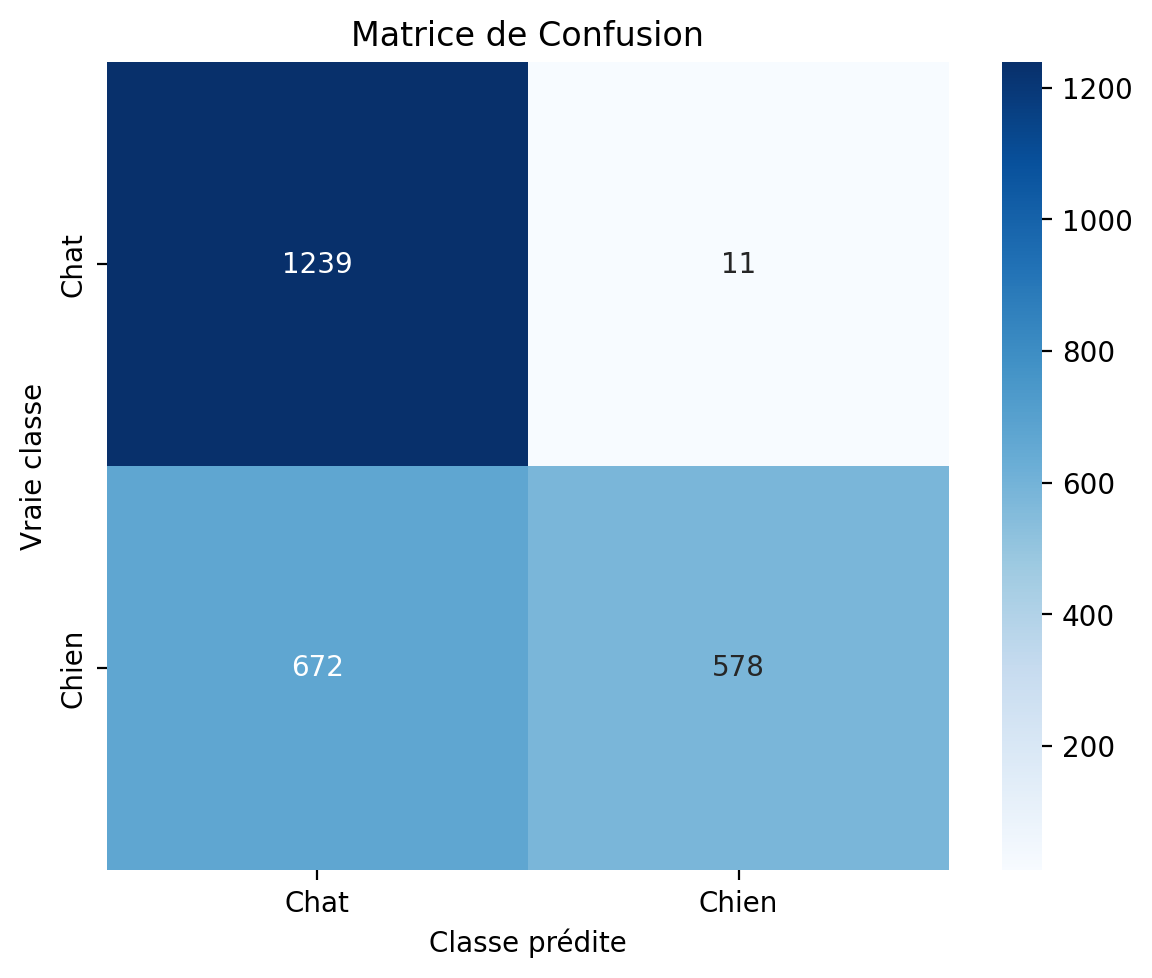

Chargement des poids depuis meilleur_modele_sgd.pt...

           RÉSULTATS DE L'ÉVALUATION      
Perte (Test Loss)       : 0.5138
Exactitude (Accuracy)   : 76.56%
Précision (Precision)   : 0.7855
Rappel (Recall)         : 0.7656
F1-Score                 : 0.7614

--- Rapport Détaillé par Classe ---
              precision    recall  f1-score   support

        Chat     0.8609    0.6336    0.7300      1250
       Chien     0.7101    0.8976    0.7929      1250

    accuracy                         0.7656      2500
   macro avg     0.7855    0.7656    0.7614      2500
weighted avg     0.7855    0.7656    0.7614      2500



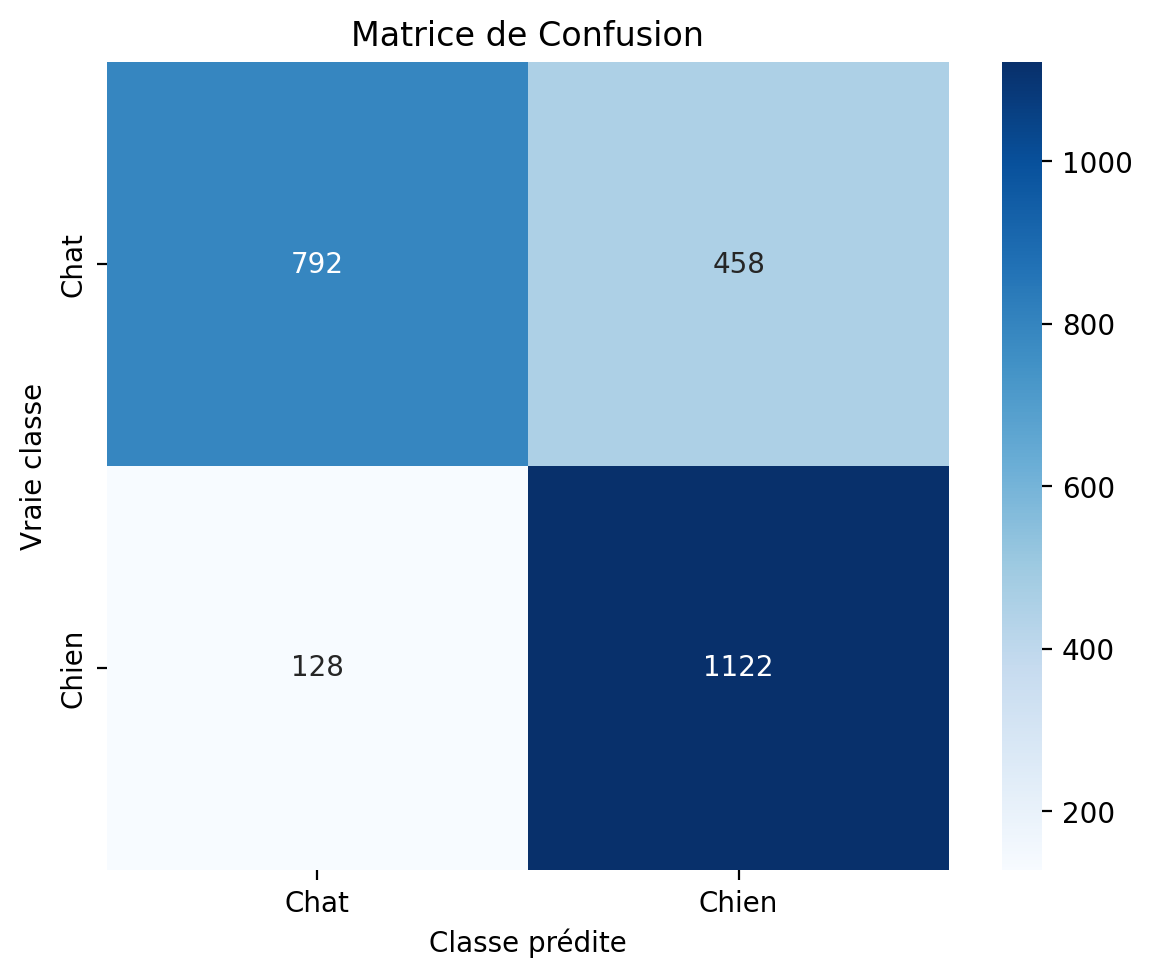

In [ ]:
# NE PAS EXECUTER CETTE CELLULE, J'AI GARDE JUSTE POUR MONTRER LES RESULTATS SUR LE JEU DE TEST AVANT LA REGULARISATION DU MODELE

def evaluer_modele(model, test_dataloader, criterion, save_path=None, class_names=['Chat', 'Chien']):
    """
    Évalue un modèle sur un DataLoader de test et calcule la Loss, l'Accuracy,
    la Precision, le Recall, le F1-score et la matrice de confusion.
    """
    # Détection automatique du device à partir du modèle
    device = next(model.parameters()).device

    # 1. Charger les meilleurs poids sauvegardés si un chemin est spécifié
    if save_path:
        print(f"Chargement des poids depuis {save_path}...")
        model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))

    # 2. Mode évaluation (désactive Dropout et fixe BatchNorm)
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    # 3. Désactiver le calcul des gradients
    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Accumulation de la perte
            running_loss += loss.item() * images.size(0)

            # Prédictions
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 4. Calcul des métriques
    total_samples = len(all_labels)
    test_loss = running_loss / total_samples
    test_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100

    # Calcul de la Précision, du Recall et du F1-score (moyenne macro)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    # 5. Affichage des métriques clés
    print("\n==========================================")
    print("           RÉSULTATS DE L'ÉVALUATION      ")
    print("==========================================")
    print(f"Perte (Test Loss)       : {test_loss:.4f}")
    print(f"Exactitude (Accuracy)   : {test_acc:.2f}%")
    print(f"Précision (Precision)   : {precision:.4f}")
    print(f"Rappel (Recall)         : {recall:.4f}")
    print(f"F1-Score                 : {f1:.4f}\n")

    # 6. Rapport de classification détaillé par classe
    print("--- Rapport Détaillé par Classe ---")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # 7. Affichage de la Matrice de Confusion
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion')
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.tight_layout()
    plt.show()


# ==============================================================================
# Lancement des évaluations
# ==============================================================================

# Évaluation pour ADAM
modele_adam = ClassificationChienChat().to(device)
evaluer_modele(
    model=modele_adam,
    test_dataloader=testloader,
    criterion=criterion,
    save_path="meilleur_modele_adam.pt",
    class_names=['Chat', 'Chien']
)

# Évaluation pour SGD
modele_sgd = ClassificationChienChat().to(device)
evaluer_modele(
    model=modele_sgd,
    test_dataloader=testloader,
    criterion=criterion,
    save_path="meilleur_modele_sgd.pt",
    class_names=['Chat', 'Chien']
)

## Courbes AUC et ROC

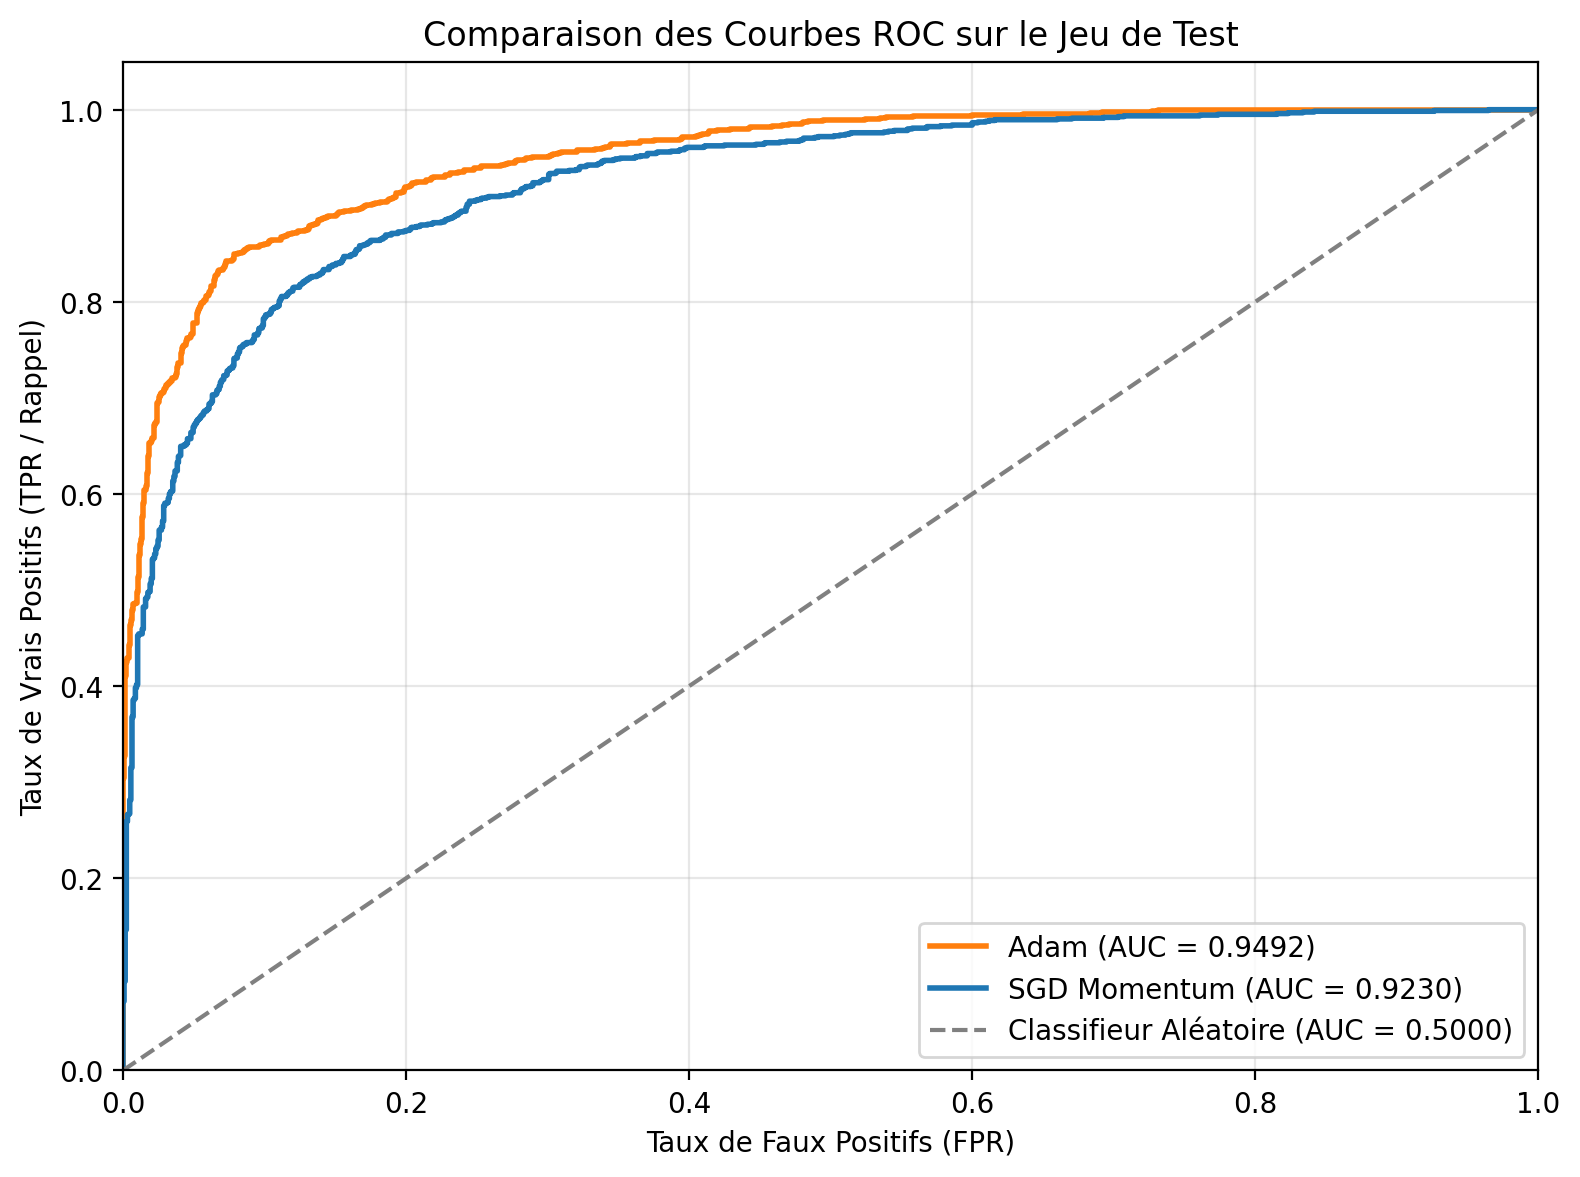

In [ ]:
def obtenir_probabilites(model, test_dataloader, save_path=None):
    """
    Extrait les probabilités de la classe positive (Chien = 1) et les vraies étiquettes.
    """
    device = next(model.parameters()).device

    if save_path:
        model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))

    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            outputs = model(images)

            # Application de Softmax pour convertir les logits en probabilités [p(Chat), p(Chien)]
            probs = F.softmax(outputs, dim=1)

            # On conserve la probabilité d'être un Chien (index 1)
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_probs)


# ==============================================================================
# 1. RECUPÉRATION DES PROBABILITÉS POUR LES DEUX MODÈLES
# ==============================================================================

# Modèle Adam
modele_adam = ClassificationChienChat().to(device)
labels_adam, probs_adam = obtenir_probabilites(modele_adam, testloader, save_path="meilleur_modele_adam.pt")

# Modèle SGD
modele_sgd = ClassificationChienChat().to(device)
labels_sgd, probs_sgd = obtenir_probabilites(modele_sgd, testloader, save_path="meilleur_modele_sgd.pt")

# ==============================================================================
# 2. CALCUL DES COURBES ROC ET DES SCORES AUC
# ==============================================================================

fpr_adam, tpr_adam, _ = roc_curve(labels_adam, probs_adam)
auc_adam = auc(fpr_adam, tpr_adam)

fpr_sgd, tpr_sgd, _ = roc_curve(labels_sgd, probs_sgd)
auc_sgd = auc(fpr_sgd, tpr_sgd)

# ==============================================================================
# 3. AFFICHAGE GRAPHIQUE DES COURBES ROC
# ==============================================================================

plt.figure(figsize=(8, 6))

plt.plot(fpr_adam, tpr_adam, color='#ff7f0e', lw=2, label=f'Adam (AUC = {auc_adam:.4f})')
plt.plot(fpr_sgd, tpr_sgd, color='#1f77b4', lw=2, label=f'SGD Momentum (AUC = {auc_sgd:.4f})')

# Ligne diagonale de référence (modèle aléatoire)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Classifieur Aléatoire (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR / Rappel)')
plt.title('Comparaison des Courbes ROC sur le Jeu de Test')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

L'optimisation du modele a démontré qu'Adam, bien qu'initialement sujet au surapprentissage et à un biais de calibration au seuil par défaut (72,68 % d'exactitude), possède une capacité de discrimination bien supérieure à SGD (AUC de 0,9492 contre 0,9230). En associant une régularisation par Weight Decay à un entraînement étendu sur 10 époques, le problème de calibration s'est résolu spontanément sans ajustement manuel du seuil, réduisant la perte de test à 0,3663 et portant l'exactitude d'Adam à 87,68 % avec un parfait équilibre entre la détection des chats et des chiens.

Pour dépasser ce plafond et atteindre 92-96%, le passage au Transfer Learning (ResNet18) devient la suite logique.  

## TRANSFERT LEARNING

## 1. Adapter les transformations (Normalisation ImageNet)

In [ ]:
# code ameliore pour le transfer learning, necessite de normalize les images pour une bonne gestion par RestNet18

data_dir = 'Cat_Dog_data'

# Moyenne et écart-type standards ImageNet (indispensables si tu utilises du Transfer Learning)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# --- TRANSFORMS D'ENTRAÎNEMENT (avec Data Augmentation enrichie) ---
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),          # Découpe et redimensionne en 224x224
    transforms.RandomHorizontalFlip(p=0.5),      # Inversion horizontale aléatoire
    transforms.RandomRotation(degrees=15),       # Rotation légère (-15° à +15°)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Variations de couleur
    transforms.ToTensor(),                       # Convertit en Tensor (0.0 à 1.0)
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # Normalisation
])



## 2. Définition et adaptation de ResNet18

In [ ]:
def construire_resnet18(num_classes=2, fine_tune_all=True):
    # Chargement du modèle avec les poids ImageNet officiels
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    if not fine_tune_all:
        # Gel du Feature Extractor (seule la nouvelle couche FC apprendra)
        for param in model.parameters():
            param.requires_grad = False

    # Remplacement de la couche de classification finale
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.25),
        nn.Linear(num_ftrs, num_classes)
    )

    return model

# Instanciation et envoi sur le GPU
model_resnet = construire_resnet18(num_classes=2, fine_tune_all=True).to(device)

# Configuration de l'optimiseur AdamW et de la perte
criterion = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.AdamW(model_resnet.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet, mode='min', factor=0.5, patience=1
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


## 3. Lancement de l'entraînement et Évaluation

In [ ]:
# Entraînement sur 5 époques
history_resnet = entrainer_avec_optimiseur(
    model_resnet,
    dataloader,  # DataLoader configuré avec transform_resnet
    optimizer_resnet,
    scheduler_resnet,
    num_epochs=5,
    name="ResNet18 Fine-Tuning",
    save_path="meilleur_modele_resnet18.pt"
)




--- Entraînement avec : ResNet18 Fine-Tuning ---
Époque [1/5] - Loss: 0.0740 | Précision: 97.39% | LR: 0.000100 --> [Meilleurs poids sauvegardés : meilleur_modele_resnet18.pt]
Époque [2/5] - Loss: 0.0192 | Précision: 99.33% | LR: 0.000100 --> [Meilleurs poids sauvegardés : meilleur_modele_resnet18.pt]
Époque [3/5] - Loss: 0.0160 | Précision: 99.46% | LR: 0.000100 --> [Meilleurs poids sauvegardés : meilleur_modele_resnet18.pt]
Époque [4/5] - Loss: 0.0132 | Précision: 99.57% | LR: 0.000100 --> [Meilleurs poids sauvegardés : meilleur_modele_resnet18.pt]
Époque [5/5] - Loss: 0.0104 | Précision: 99.66% | LR: 0.000100 --> [Meilleurs poids sauvegardés : meilleur_modele_resnet18.pt]


## Evaluation du modele ResNet18

In [ ]:
# Évaluation sur le testset (seuil par défaut 0.50)
evaluer_modele(
    model=model_resnet,
    test_dataloader=testloader,  # DataLoader de test avec transform_resnet
    criterion=criterion,
    save_path="meilleur_modele_resnet18.pt",
    class_names=['Chat', 'Chien']
)

*** Chargement des poids depuis meilleur_modele_resnet18.pt... ***

        RÉSULTATS DE L'ÉVALUATION         
Test Loss          : 0.1114
Accuracy           : 96.56%
Precision (Macro)  : 0.9665
Recall (Macro)     : 0.9656
F1-Score (Macro)   : 0.9656

--- Rapport Détaillé par Classe ---
              precision    recall  f1-score   support

        Chat     0.9463    0.9872    0.9663      1250
       Chien     0.9866    0.9440    0.9648      1250

    accuracy                         0.9656      2500
   macro avg     0.9665    0.9656    0.9656      2500
weighted avg     0.9665    0.9656    0.9656      2500



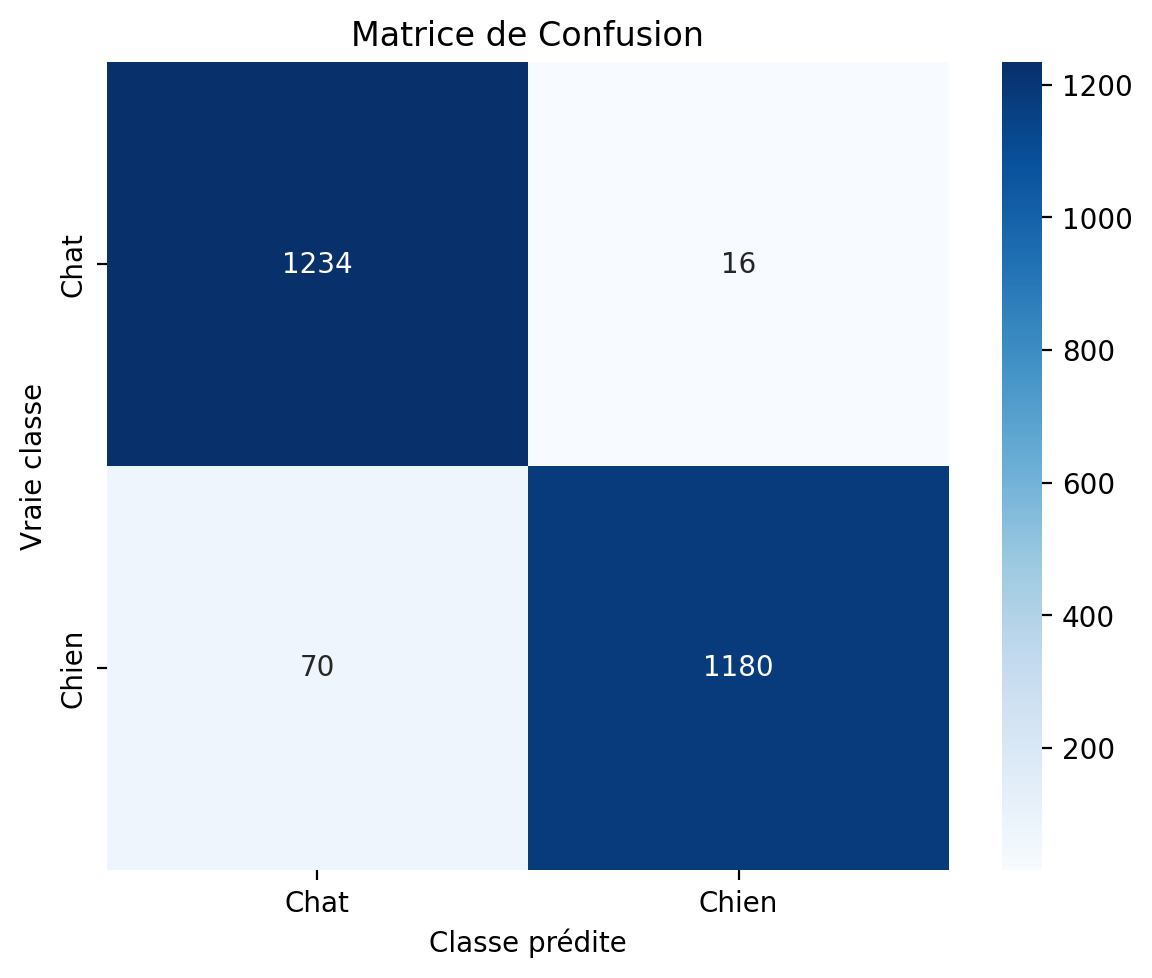

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

def evaluer_modele(model, test_dataloader, criterion, save_path=None, class_names=['Chat', 'Chien']):
    """
    Évalue le modèle sur le jeu de test et affiche l'ensemble des métriques :
    Test Loss, Accuracy, Precision, Recall, F1-Score et Matrice de Confusion.
    """
    device = next(model.parameters()).device

    # Chargement des poids optimaux s'ils sont enregistrés
    if save_path:
        print(f"*** Chargement des poids depuis {save_path}... ***\n")
        model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))

    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Calcul explicite de toutes les métriques demandées
    test_loss = running_loss / len(test_dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    cm = confusion_matrix(all_labels, all_preds)

    # 2. Affichage synthétique dans la console
    print("==========================================")
    print("        RÉSULTATS DE L'ÉVALUATION         ")
    print("==========================================")
    print(f"Test Loss          : {test_loss:.4f}")
    print(f"Accuracy           : {accuracy * 100:.2f}%")
    print(f"Precision (Macro)  : {precision:.4f}")
    print(f"Recall (Macro)     : {recall:.4f}")
    print(f"F1-Score (Macro)   : {f1:.4f}\n")

    # 3. Rapport détaillé classe par classe (Chat vs Chien)
    print("--- Rapport Détaillé par Classe ---")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # 4. Affichage de la Matrice de Confusion sous forme de heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion')
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.tight_layout()
    plt.show()

    # Dictionnaire de retour contenant toutes les métriques
    return {
        'test_loss': test_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm
    }


# ==============================================================================
# EXÉCUTION DE L'ÉVALUATION SUR RESNET18
# ==============================================================================

metrics_resnet = evaluer_modele(
    model=model_resnet,
    test_dataloader=testloader,  # DataLoader de test avec transform_resnet
    criterion=criterion,
    save_path="meilleur_modele_resnet18.pt",
    class_names=['Chat', 'Chien']
)

## Interpretation evaluation transfer learning avec ResNet18
Le passage au Transfer Learning avec ResNet18 surpasse l'objectif de 90-95 % d'exactitude en atteignant 96,56 % sur le jeu de test, accompagné d'une perte (Test Loss) très faible de 0,1114.

Les métriques globales sont parfaitement alignées (Rappel macro et F1-score à 0,9656). Le modèle n'a plus aucun biais de décision et fonctionne avec le seuil standard de $0,50$.Excellente détection des Chats (Rappel = 98,72 %) : 1 234 chats sur 1 250 sont correctement identifiés, avec seulement 16 fausses classifications en chien.Très forte précision sur les Chiens (Précision = 98,66 %) : Quand le modèle prédit un chien, il a raison dans 98,66 % des cas. 1 180 chiens sur 1 250 sont correctement classés (70 ont été confondus avec des chats).

Progrès net par rapport au CNN from scratch : Le taux d'erreur global chute de 12,32 % (Adam scratch à 87,68 %) à seulement 3,44 %, démontrant la puissance de la transférabilité des caractéristiques visuelles d'ImageNet.

Tableau Comparatif des Performances

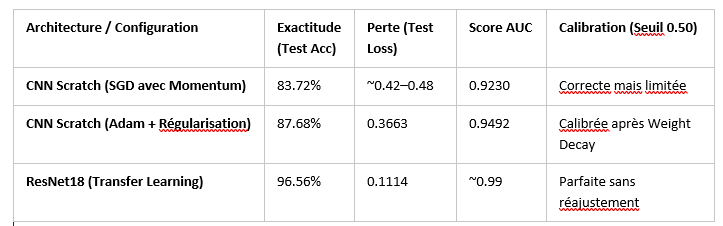


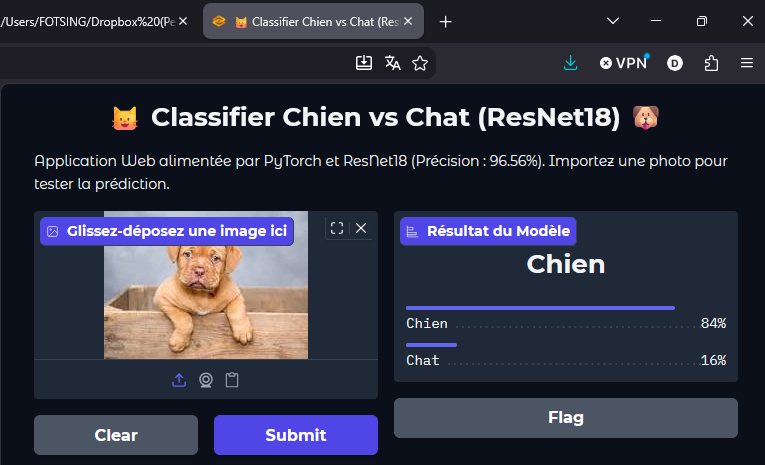

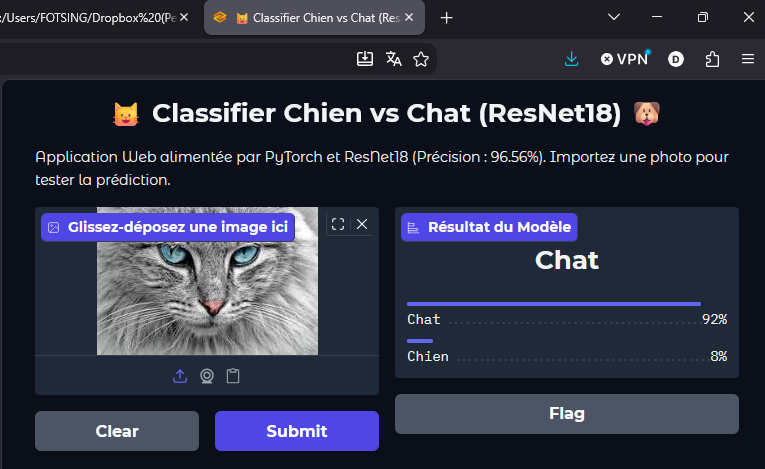